<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/10_Wasserstein_GAN_with_Gradient_Penalty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import PyTorch for implementing the Generator and Critic networks.
import torch

# Import neural network building blocks.
import torch.nn as nn

# Import TorchVision utilities for image datasets.
import torchvision

# Import Matplotlib for visualizing generated images
# and monitoring training progress.
import matplotlib.pyplot as plt

In [2]:
# Build the Generator network.
# The Generator transforms random latent vectors
# into synthetic images.

class Generator(nn.Module):

    def __init__(self, latent_dim=100):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim,256),

            nn.ReLU(),

            nn.Linear(256,512),

            nn.ReLU(),

            nn.Linear(512,784),

            nn.Tanh()

        )

    def forward(self,z):

        # Generate synthetic images from latent vectors.
        return self.model(z)

In [3]:
# Build the Critic network.
# The Critic estimates the Wasserstein distance
# between real and generated data distributions.

class Critic(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784,512),

            nn.LeakyReLU(0.2),

            nn.Linear(512,256),

            nn.LeakyReLU(0.2),

            nn.Linear(256,1)

        )

    def forward(self,x):

        # Produce a critic score instead of
        # a probability value.
        return self.model(x)

In [4]:
# Compute the Wasserstein Loss.
# The Critic maximizes the score difference
# between real and generated samples.

def wasserstein_loss(real_score,fake_score):

    return fake_score.mean() - real_score.mean()

In [5]:
# Compute the Wasserstein Loss.
# The Critic maximizes the score difference
# between real and generated samples.

def wasserstein_loss(real_score,fake_score):

    return fake_score.mean() - real_score.mean()

In [6]:
# Compute the Gradient Penalty.
# The penalty enforces the Lipschitz-1 constraint
# by keeping the gradient norm close to one.

def gradient_penalty(

    critic,

    real,

    fake

):

    # Generate interpolation coefficients.
    alpha = torch.rand(real.size(0),1)

    alpha = alpha.expand_as(real)

    # Create interpolated samples between
    # real and generated images.
    interpolated = alpha * real + (1-alpha) * fake

    interpolated.requires_grad_(True)

    # Evaluate interpolated samples using the Critic.
    critic_output = critic(interpolated)

    # Compute gradients with respect to
    # interpolated samples.
    gradients = torch.autograd.grad(

        outputs=critic_output,

        inputs=interpolated,

        grad_outputs=torch.ones_like(critic_output),

        create_graph=True,

        retain_graph=True

    )[0]

    # Compute the Gradient Penalty term.
    penalty = (

        gradients.norm(2,dim=1)-1

    )**2

    return penalty.mean()

In [7]:
# Create Generator and Critic models.

generator = Generator()

critic = Critic()

In [8]:
# Generate latent vectors that serve as
# the input to the Generator.

latent = torch.randn(32,100)

In [9]:
# Produce synthetic images using
# the Generator.

fake_images = generator(latent)

In [10]:
# Evaluate real and generated images
# using the Critic.

real_images = torch.randn(32,784)

real_score = critic(real_images)

fake_score = critic(fake_images.detach())

In [11]:
# Compute Wasserstein Loss.

critic_loss = wasserstein_loss(

    real_score,

    fake_score

)

# Compute Gradient Penalty.

gp = gradient_penalty(

    critic,

    real_images,

    fake_images.detach()

)

# Combine both losses to stabilize training.

total_loss = critic_loss + 10 * gp

print("Critic Loss :",total_loss.item())

Critic Loss : 8.168984413146973


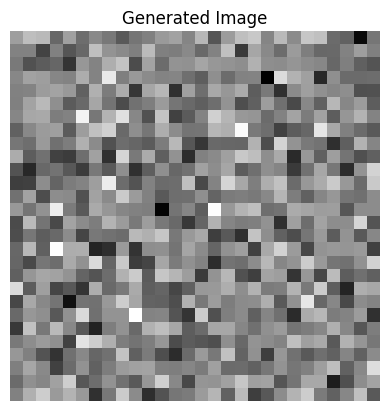

In [12]:
# Display a generated image produced
# by the Generator.

plt.imshow(

    fake_images[0].view(28,28).detach().numpy(),

    cmap="gray"

)

plt.title("Generated Image")

plt.axis("off")

plt.show()